In [36]:

import numpy as np
import scipy
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from scipy.optimize import minimize
from iminuit.cost import LeastSquares

from iminuit import Minuit

sns.set_context("paper", font_scale=1.4)
sns.set_style("ticks")


## asked chat to make a polar inspirede colormap
pallete = [
    "#234F5C",  # deep fjord teal (dark)
    "#F2A47D",  # arctic sunset orange
    "#9975B1",  # low sun gold
    "#98FDEE",  # electric ice cyan
        "#8DF596",  # frozen horizon red

    "#1F7A8C",  # glacial lagoon
    "#FF4E88",  # polar pink sky
    "#2E294E",  # polar night indigo
    "#541388",  # aurora violet
    "#3A5A40",  # tundra moss
    "#A1E3F9",  # fractured ice blue
    "#8E44AD",  # deep aurora magenta
    "#00B3A4",  # icy turquoise
]

plt.rcParams["axes.prop_cycle"] = plt.cycler("color", pallete)

plt.rcParams['figure.figsize'] = (16, 9)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.facecolor'] =     "#DDDCDC"  # frozen mist (very light)
## color of legend frame
plt.rcParams["legend.facecolor"] = "#FFFFFF"
plt.rcParams["legend.edgecolor"] = "#010003"
plt.rcParams["legend.framealpha"] = .9

rc = {"font.family" : "serif", 
      "mathtext.fontset" : "stix"}
plt.rcParams.update(rc)
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
mpl_markers = ['o', 'v', 's', 'p', '*', 'P', 'd']

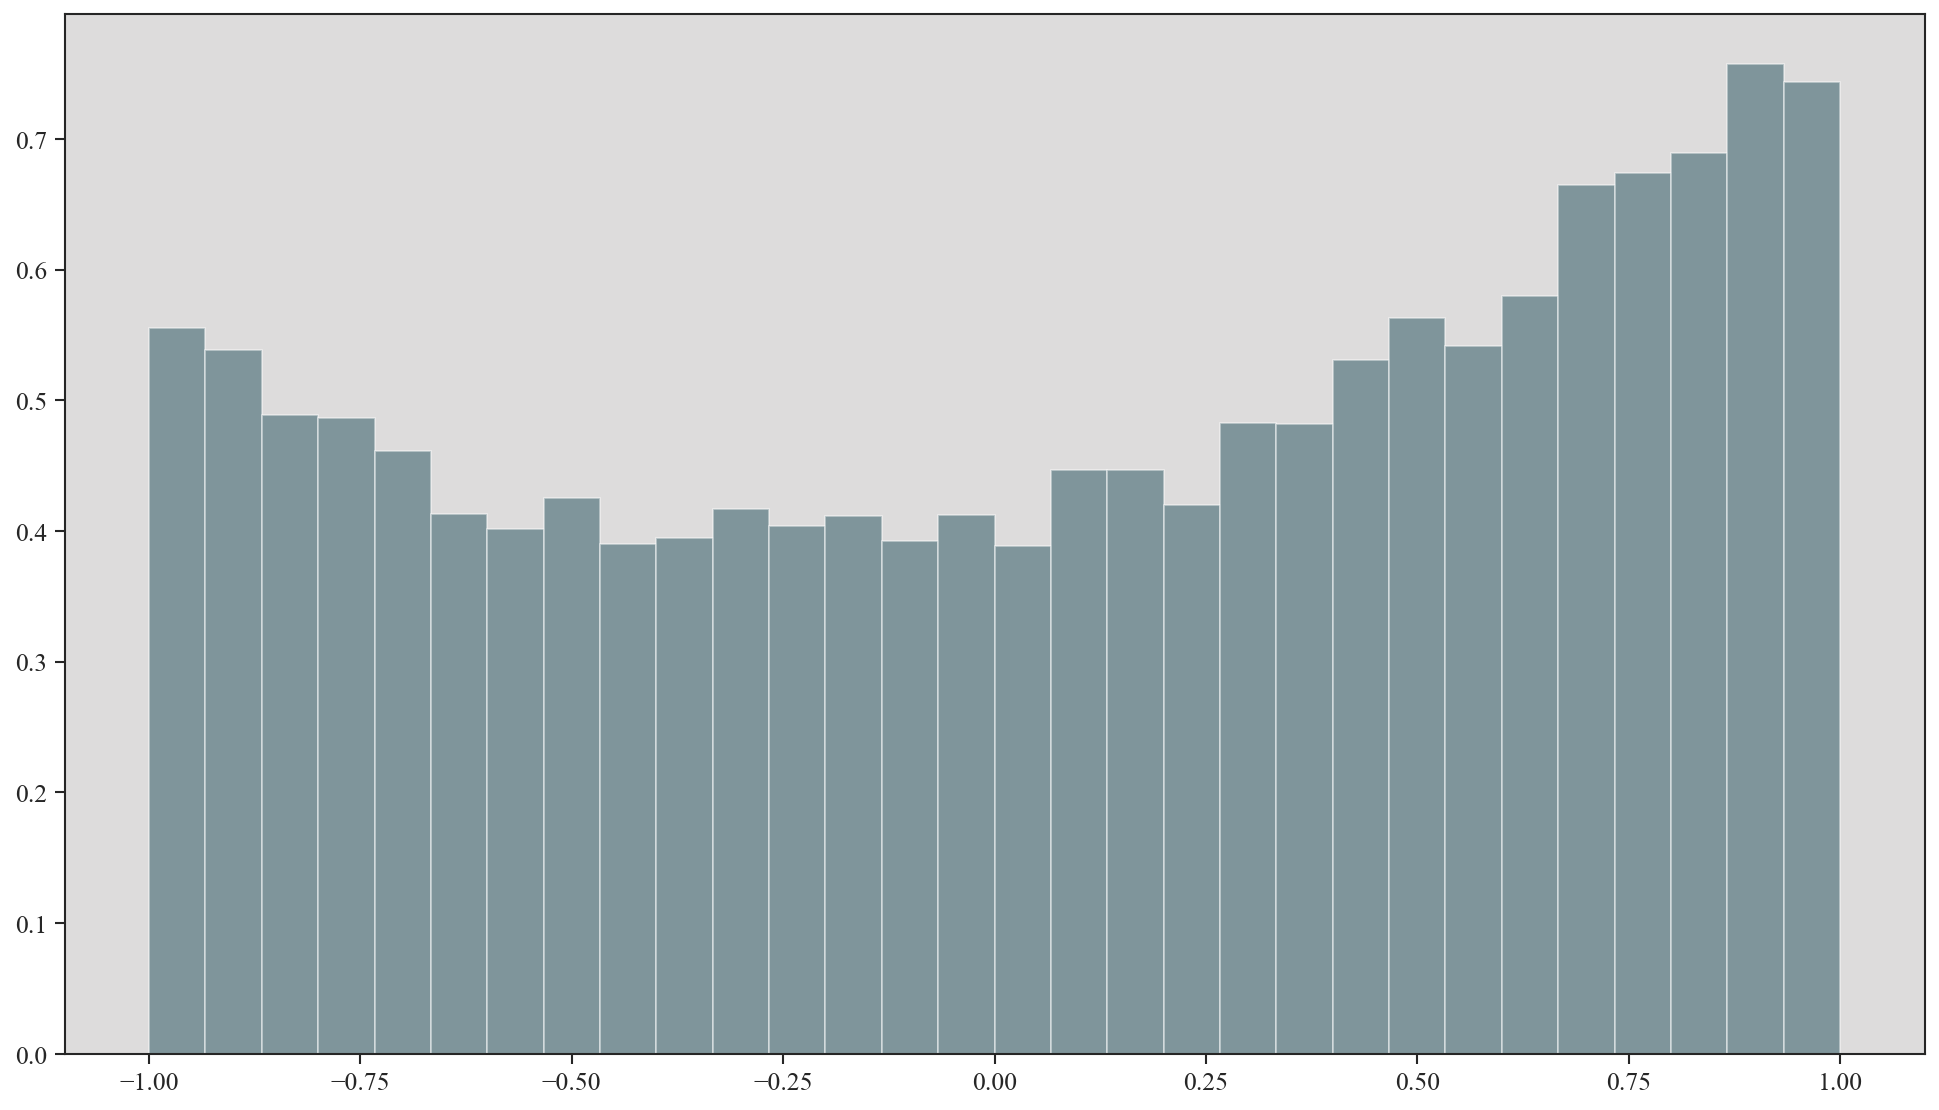

In [93]:
dat1 = np.genfromtxt("/Users/jeppegrejspetersen/Code/AMAS(APPSTAT2)/week4/LLH_Ratio_2_data.txt")[:,0]
# dat2 = np.genfromtxt("/Users/jeppegrejspetersen/Code/AMAS(APPSTAT2)/week4/LLH_Ratio_2a_data.txt")[:,0]
plt.hist(dat1, bins = 30, density = True, alpha = 0.5, label = "dat1");

In [88]:
def null_pdf(x, p, w):
    def f(x, p,w):
        return 1 + p*x + w*x**2

    Z, _ = scipy.integrate.quad(
    lambda t: f(t, p, w),
    -1,
    1
    )
    return f(x,p,w)/Z

def alt_pdf(x, p, w, g):
    def f(x, p,w,g):
        return 1 + p*x + w*x**2 - g*x**5
    Z, _ = scipy.integrate.quad(
    lambda t: f(t, p, w, g),
    -1,
    1
    )
    return f(x,p,w,g)/Z


def like_null_dat(p,w):
    return - np.sum(np.log(null_pdf(dat1,p,w)))

def like_alt_dat(p,w,g):
    return - np.sum(np.log(alt_pdf(dat1,p,w,g )))


def test_statistis(params_nul, params_alt):
    return 2 * ( like_null_dat(*params_nul) - like_alt_dat(*params_alt)) ### UNSURE ABOUT SIGN



In [89]:
## minuit unbinned likelihood
m_null = Minuit(like_null_dat, p = 0, w = 0)
m_null.migrad()

print("NEG ln like for null:", like_null_dat(m_null.values["p"], m_null.values["w"]))
m_null.migrad()

NEG ln like for null: 13432.139552295735


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.343e+04                  │              Nfcn = 58               │
│ EDM = 1.01e-11 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ p    │   0.299   │   0.023   │            │            │         │         │       │
│ 1 │ w    │   0.66    │   0.05    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────┐
│   │        p        w │
├───┼───────────────────┤
│ p │ 0.000528   0.3e-3 │
│ w │   0.3e-3  0.00262 │
└───┴───────────────────┘

In [90]:
m_alt = Minuit(like_alt_dat, p = 0, w = 0, g = 0)
m_alt.migrad()
print("NEG ln like for alt:", like_alt_dat(m_alt.values["p"], m_alt.values["w"], m_alt.values["g"]))
m_alt.migrad()

NEG ln like for alt: 13431.405414731027


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.343e+04                  │              Nfcn = 117              │
│ EDM = 1.83e-11 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ p    │   0.32    │   0.04    │            │            │         │         │       │
│ 1 │ w    │   0.66    │   0.05    │            │            │         │         │       │
│ 2 │ g    │   0.06    │   0.08    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────────────────────┐
│   │       p       w       g │
├───┼─────────────────────────┤
│ p │ 0.00135  0.0001  0.0022 │
│ w │  0.0001 0.00266 -0.0004 │
│ g │  0.0022 -0.0004 0.00563 │
└───┴─────────────────────────┘

In [94]:
test_stat = test_statistis((m_null.values["p"], m_null.values["w"]), (m_alt.values["p"], m_alt.values["w"], m_alt.values["g"]))
print("Test statistic:", test_stat)

Test statistic: 1.468271268371609


In [95]:
scipy.stats.chi2.sf(test_stat, df = 1) ## only 1 dof since g is the only extra parameter in alt model

np.float64(0.22561864678113644)

### so in this case, we would not disgard the 0-hyp given a sig-level og 5 % (which is not what we do in this course)

For the other case, it is near 0, so we can discard the 0-hyp, and say it is the better distribution

In [97]:
!micromamba install -c conda-forge healpy -y

[+] 0.0s
[+] 0.1s
conda-forge/noarch    ━━━━━━━━━━━━━━━━━━━━━━   8.6kB /  24.8MB @ 120.9kB/s  0.0s
conda-forge/osx-arm64 ━━━━━╸━━━━━━━━━━━━━━━━   0.0 B /  ??.?MB @  ??.?MB/s  0.0s[+] 0.2s
conda-forge/noarch    ━━━━━━━━━━━━━━━━━━━━━━   1.1MB /  24.8MB @   6.3MB/s  0.1s
conda-forge/osx-arm64 ━━━━━━━━━━━━━━━━━━━━━━ 543.8kB /  20.6MB @   3.1MB/s  0.1s[+] 0.3s
conda-forge/noarch    ╸━━━━━━━━━━━━━━━━━━━━━   1.7MB /  24.8MB @   6.0MB/s  0.2s
conda-forge/osx-arm64 ╸━━━━━━━━━━━━━━━━━━━━━   1.1MB /  20.6MB @   3.8MB/s  0.2s[+] 0.4s
conda-forge/noarch    ━╸━━━━━━━━━━━━━━━━━━━━   2.7MB /  24.8MB @   6.8MB/s  0.3s
conda-forge/osx-arm64 ╸━━━━━━━━━━━━━━━━━━━━━   1.6MB /  20.6MB @   4.0MB/s  0.3s[+] 0.5s
conda-forge/noarch    ━╸━━━━━━━━━━━━━━━━━━━━   2.9MB /  24.8MB @   6.4MB/s  0.4s
conda-forge/osx-arm64 ━╸━━━━━━━━━━━━━━━━━━━━   2.1MB /  20.6MB @   4.7MB/s  0.4s[+] 0.6s
conda-forge/noarch    ━╸━━━━━━━━━━━━━━━━━━━━   2.9MB /  24.8MB @   6.4MB/s  0.5s
conda-forge/osx-arm64 ━╸━━━━━━━━━━━━━━━━━━━━   2.1M